# Tutorial 02: Boltzmann Transport



In this tutorial you will continue the post-processing workflow on bulk silicon: interpolate the PAO Hamiltonian on a dense Brillouin-zone grid, compute momentum matrix elements, evaluate Boltzmann transport tensors, and extend the calculation with relaxation-time models. It is intended for readers who have completed Tutorial 01 and know the basic Hamiltonian workflow.



Since this example runs easily on a laptop, the shared asset archive provides only the Quantum ESPRESSO `silicon.save` input. You will generate every PAOFLOW output while running this notebook.



**What you will learn**



- How interpolated velocities enter the Boltzmann transport tensors

- How the electrical conductivity, Seebeck coefficient, and electronic thermal conductivity are computed in the constant relaxation-time approximation

- How to inspect the transport tensors written by the calculation

- How to replace the constant relaxation time with user-defined and built-in scattering models



**Estimated runtime:** A few minutes on a typical workstation for the supplied silicon data.

::: {tip}

{download}`Download Tutorial 02 as a Jupyter notebook <tutorial02.ipynb>`.

:::



## Required Input



This tutorial reuses the `silicon.save` input owned by [Tutorial 01](tutorial01.ipynb). The input is the output of a Quantum ESPRESSO calculation of bulk silicon using the PBE exchange-correlation approximation and the `Si.pbe-tm-new-gipaw-v2.1.UPF` pseudopotential. It is distributed in the [PAOFLOW tutorial asset archive](https://github.com/marcobn/PAOFLOW/releases/download/tutorial-assets-v1/tutorial_assets.tar.gz).



Since the complete workflow runs quickly on a laptop, the archive contains only the QE input and no precomputed PAOFLOW results:



- `data-file-schema.xml` - silicon crystal structure, k-point grid, and Kohn-Sham eigenvalues

- `atomic_proj.xml` - projection amplitudes and overlap matrices

- `Si.pbe-tm-new-gipaw-v2.1.UPF` - the PBE silicon pseudopotential used to generate the data



The transport workflow starts from the same PAO Hamiltonian and adds the quantities needed for Brillouin-zone transport integrals.

## Prepare the supplied tutorial input



This setup step exists only to retrieve the pre-generated input used by the tutorial. In your own workflow, set `savedir` to the Quantum ESPRESSO `.save` directory produced by your calculation.

In [1]:
from pathlib import Path

from tarfile import open as open_tar

from urllib.request import urlretrieve


asset_url = (
    'https://github.com/marcobn/PAOFLOW/releases/download/'
    'tutorial-assets-v1/tutorial_assets.tar.gz'
)

archive_path = Path('tutorial_assets.tar.gz')

asset_prefix = 'tutorial01/'

savedir = Path('tutorial01/silicon.save')

outputdir = 'output'


if not savedir.is_dir():
    if not archive_path.is_file():
        urlretrieve(asset_url, archive_path)

    with open_tar(archive_path, 'r:gz') as archive:
        members = [
            member for member in archive.getmembers() if member.name.startswith(asset_prefix)
        ]

        if not members:
            raise FileNotFoundError(f'{asset_prefix} is missing from {archive_path}')

        archive.extractall(path='.', members=members)

## 1. Initialise PAOFLOW and build the transport-ready Hamiltonian



The next cell first creates the `PAOFLOW` object with the extracted Quantum ESPRESSO `.save` directory and the `output` destination. Only after that initialization does it read the atomic projections, check projectability, build and interpolate the PAO Hamiltonian, and compute the momentum matrix elements needed for transport.



Tutorial 01 explains these preparation steps individually. They are combined here so that this notebook can focus on transport.

In [2]:
import matplotlib.pyplot as plt

import numpy as np

from scipy.constants import hbar


from PAOFLOW import PAOFLOW

from PAOFLOW.boltzmann.TauModel import TauModel


paoflow = PAOFLOW.PAOFLOW(
    savedir=str(savedir),
    outputdir=outputdir,
    smearing='gauss',
    npool=1,
    verbose=True,
)


paoflow.read_atomic_proj_QE()

paoflow.projectability()

paoflow.pao_hamiltonian()

paoflow.interpolated_hamiltonian()

paoflow.pao_eigh()

paoflow.gradient_and_momenta()

paoflow.adaptive_smearing()


────────────────────────────────────────────────────────────────────────────────────
   
           ██████╗  █████╗  ██████╗ ███████╗██╗      ██████╗ ██╗    ██╗
           ██╔══██╗██╔══██╗██╔═══██╗██╔════╝██║     ██╔═══██╗██║    ██║
           ██████╔╝███████║██║   ██║█████╗  ██║     ██║   ██║██║ █╗ ██║
           ██╔═══╝ ██╔══██║██║   ██║██╔══╝  ██║     ██║   ██║██║███╗██║
           ██║     ██║  ██║╚██████╔╝██║     ███████╗╚██████╔╝╚███╔███╔╝
           ╚═╝     ╚═╝  ╚═╝ ╚═════╝ ╚═╝     ╚══════╝ ╚═════╝  ╚══╝╚══╝
           
────────────────────────────────────────────────────────────────────────────────────
   From DFT wavefunctions to materials properties via atomic-orbital Hamiltonians   
────────────────────────────────────────────────────────────────────────────────────

Insulator: True
Magnetic: False
Number of kpoints: 72
Number of electrons: 8.000000
Number of bands: 18
DFT Fermi energy: 5.264635162 eV
Monkhorst and Pack grid: 12 12 12 0 0 0
Serial execution
Estimated maximum

## 2. Compute and plot transport tensors



Within the Boltzmann transport framework and the constant relaxation-time approximation, the electrical conductivity tensor is:



$$

\sigma_{\mu\nu}(E) = e^2\tau\,\frac{1}{N_k}\sum_{n,\mathbf{k}} v^\mu_{n\mathbf{k}}\,v^\nu_{n\mathbf{k}} \left(-\frac{\partial f}{\partial\varepsilon}\right)_{\varepsilon_{n\mathbf{k}}}

$$



Here $\tau$ is the (assumed constant) relaxation time and $f$ is the Fermi-Dirac distribution. PAOFLOW also computes the Seebeck coefficient and electronic thermal conductivity from energy-weighted moments of the same expression. All tensors are functions of chemical potential.



**Output:**



`kappagauss_0.dat` - contains the electronic thermal conductivity as a function of temperature.



`PFgauss_0.dat` - contains the power factor as a function of temperature.



`Seebeckgauss_0.dat` - contains the Seebeck coefficient as a function of temperature.



`sigmagauss_0.dat` - contains the electrical conductivity as a function of temperature.



The plotting cell uses PAOFLOW's predefined `GPAO.plot_electrical_conductivity()` and `GPAO.plot_seebeck()` functions for the quantities supported by GPAO. Thermal conductivity and power factor are plotted directly because GPAO does not currently provide dedicated functions for them.

In [3]:
paoflow.transport(emin=-12.0, emax=2.2)

Transport in:                              24.041 sec


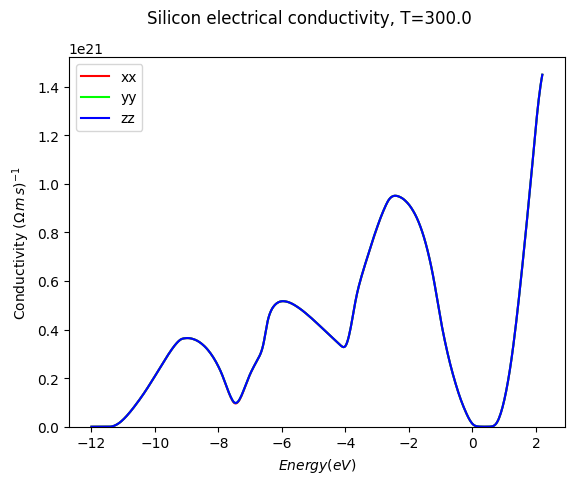

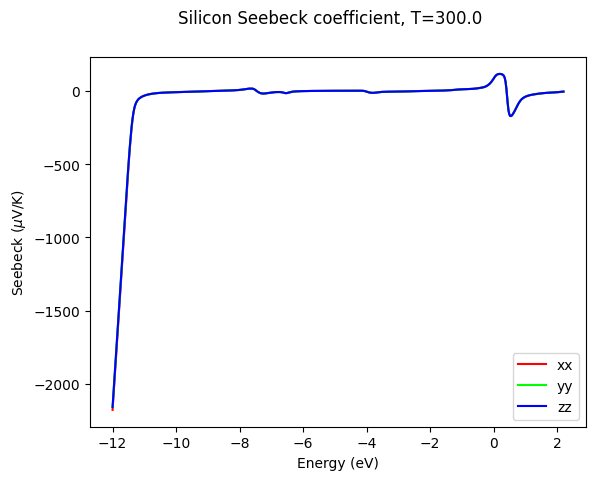

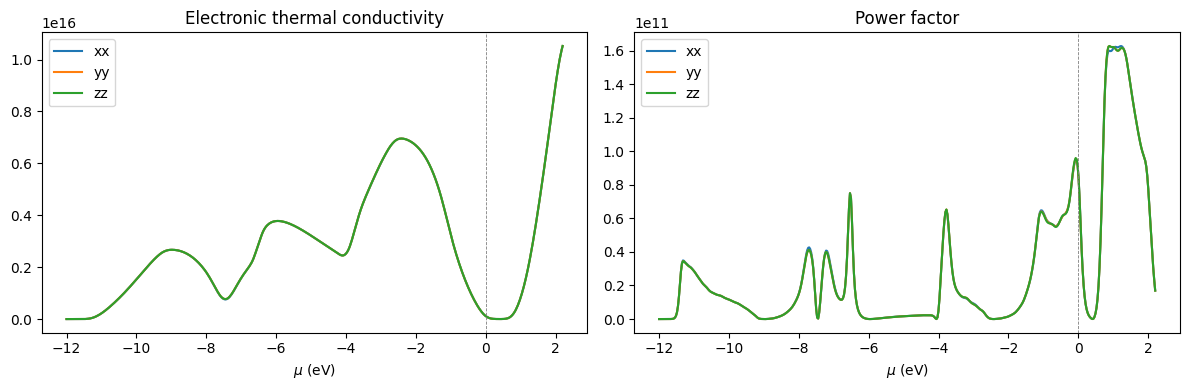

In [4]:
from PAOFLOW import GPAO


sigma_file = Path(outputdir) / 'sigmagauss_0.dat'

seebeck_file = Path(outputdir) / 'Seebeckgauss_0.dat'

kappa_file = Path(outputdir) / 'kappagauss_0.dat'

pf_file = Path(outputdir) / 'PFgauss_0.dat'


plotter = GPAO.GPAO()

plotter.plot_electrical_conductivity(
    str(sigma_file),
    title='Silicon electrical conductivity',
)

plotter.plot_seebeck(
    str(seebeck_file),
    title='Silicon Seebeck coefficient',
)


datasets = [
    ('Electronic thermal conductivity', np.loadtxt(kappa_file)),
    ('Power factor', np.loadtxt(pf_file)),
]

tensor_labels = ['xx', 'yy', 'zz']

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)


for axis, (title, data) in zip(axes, datasets):
    data = np.atleast_2d(data)

    chemical_potential = data[:, 1]

    for index, label in enumerate(tensor_labels):
        axis.plot(chemical_potential, data[:, index + 2], label=label)

    axis.axvline(0.0, color='gray', linestyle='--', linewidth=0.6)

    axis.set_title(title)

    axis.set_xlabel(r'$\mu$ (eV)')

    axis.legend()


fig.tight_layout()

plt.show()

For cubic silicon, the three diagonal tensor components should lie on top of each other within numerical accuracy. Small differences are usually a sign that the k-grid or energy resolution should be increased.


## 3. Relaxation-time models

The calculation above uses the constant relaxation-time approximation. PAOFLOW can also replace the constant $\tau$ with a list of scattering models supplied through `scattering_channels`.

Within the Boltzmann transport framework, the conductivity tensor in the constant-$\tau$ approximation is:

$$
\sigma_{\mu\nu}(E) = e^2\tau\,\frac{1}{N_k}\sum_{n,\mathbf{k}} v^\mu_{n\mathbf{k}}\,v^\nu_{n\mathbf{k}} \left(-\frac{\partial f}{\partial\varepsilon}\right)_{\varepsilon_{n\mathbf{k}}}
$$

Each channel may be either:

- the name of a built-in model such as `'acoustic'`, `'optical'`, `'impurity'`, `'polar_optical'`, or `'polar_acoustic'`
- a user-defined `TauModel` object

When several channels are included, PAOFLOW combines them using Matthiessen's rule:

$$
\frac{1}{\tau_{\mathrm{tot}}} = \sum_c \frac{w_c}{\tau_c}
$$

### 3.1 Start with built-in channels

A practical first step is to use only built-in relaxation channels. The snippet below uses acoustic and ionised-impurity scattering and defines the corresponding `tau_dict` parameters.

After validating this baseline setup, you can introduce a custom model and mix it with the built-ins. Note that all parameters used in the relaxation-time models are only for demonstration purposes and may not represent a realistic description of silicon.

In [5]:
channels = ['acoustic', 'impurity']

tau_parameters = {
    'nI': 1.0e17,
    'Zi': 1,
    'ms': 0.26,
    'eps_0': 11.7,
    'eps_inf': 11.7,
}

### 3.2 Define a custom TauModel and combine channels

The example below defines a compact acoustic-phonon `TauModel` and replaces the built-in acoustic channel while keeping ionised-impurity scattering. For polar semiconductors one may extend the same list with `'polar_optical'` and `'polar_acoustic'`.

In [6]:
ELECTRON_MASS = 9.1093837e-31
EV_TO_J = 1.602176634e-19


def acoustic_tau(temp, eigs, params):
    temp_j = temp * EV_TO_J
    energy_j = np.clip(eigs, 0.0, None) * EV_TO_J

    sound_velocity = params['v']
    mass_density = params['rho']
    effective_mass = params['ms'] * ELECTRON_MASS
    deformation = params['D_ac'] * EV_TO_J

    tau = np.full_like(energy_j, np.inf, dtype=float)
    mask = energy_j > 0.0

    rate = (
        (2 * effective_mass) ** 1.5
        * deformation**2
        * np.sqrt(energy_j[mask])
        * temp_j
        / (2 * np.pi * mass_density * (hbar**2 * sound_velocity) ** 2)
    )
    tau[mask] = 1.0 / rate
    return tau


custom_channel = TauModel(
    function=acoustic_tau,
    params={'v': 9.0e3, 'rho': 2.33e3, 'ms': 0.26, 'D_ac': 5.0},
)

channels = [custom_channel, 'impurity']

### 3.3 Compute the chemical potential for a target doping

A temperature-dependent transport calculation usually starts from a fixed carrier density. `doping()` solves for the chemical potential $\mu(T)$ that reproduces the requested concentration.

**Output:**

`doping_*.dat` - contains the Fermi level $\mu(T)$ as a function of temperature required to keep the carrier density fixed.

In [7]:
doping_conc = -1.0e17

paoflow.doping(
    tmin=300.0,
    tmax=800.0,
    nt=11,
    emin=-2.0,
    emax=2.0,
    ne=4001,
    doping_conc=doping_conc,
)

temperature, mu = np.loadtxt(
    'output/doping_n1e+17.dat',
    usecols=(0, 1),
    unpack=True,
)

Writing Adaptive DoS Files
Doping in:                                 47.912 sec


### 3.4 Run transport one temperature at a time

The loop below evaluates `transport()` at each $(T, \mu)$ pair. `save_tensors=True` keeps the tensors in memory, which makes it straightforward to extract a scalar conductivity and convert it to a resistivity curve.

The `Ef` entry in `tau_parameters` is updated inside the loop because some built-in models use the current chemical potential as an input parameter.

In [ ]:
arry, attr = paoflow.data_controller.data_dicts()
rho = []

attr['tau_dict'] = dict(tau_parameters)

for t, m in zip(temperature, mu):
    ef = abs(m)
    attr['tau_dict']['Ef'] = ef

    paoflow.transport(
        tmin=t,
        tmax=t,
        nt=1,
        emin=m,
        emax=m,
        ne=1,
        scattering_channels=channels,
        tau_dict=attr['tau_dict'],
        save_tensors=True,
        write_to_file=False,
    )

    sigma = np.trace(arry['sigma'][:, :, 0]) / 3.0
    rho.append(1e2 / sigma)

rho = np.array(rho)

Transport in:                               1.089 sec
Transport in:                               1.100 sec
Transport in:                               1.121 sec
Transport in:                               0.993 sec
Transport in:                               1.086 sec
Transport in:                               0.961 sec
Transport in:                               0.930 sec
Transport in:                               0.920 sec
Transport in:                               0.919 sec
Transport in:                               1.020 sec
Transport in:                               0.937 sec


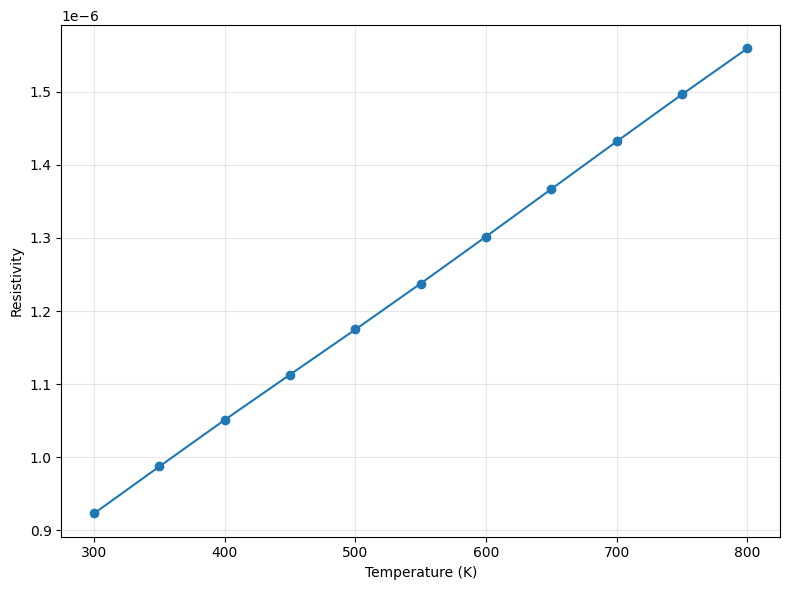

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(temperature, rho, 'o-', lw=1.5)
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Resistivity')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

This split example shows the pieces that matter for relaxation-time models: defining a `TauModel`, mixing it with built-in channels, solving for $\mu(T)$ at fixed doping, and then running `transport()` one temperature at a time.


In [ ]:
paoflow.finish_execution()

Total CPU time =                           52.914 sec
Memory usage on rank 0:  1.6434 GB
Maximum concurrent memory usage:  1.6434 GB


## 4. Further reading
- For more details on the code framework of the relaxation-time models, refer to the [PAOFLOW documentation](https://paoflow.readthedocs.io/en/latest/transport.html#relaxation-time-models).
- For more details on the various scattering models and their application to other materials, refer to [Relaxation time approximations in PAOFLOW 2.0](https://doi.org/10.1038/s41598-022-08931-5)